## ✨ Pride and Prejudice Data Lake Analysis ✨

### Imports and config

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# 🎪 Life of a Showgirl palette
SHOWGIRL = {
    'orange': '#e46c32',
    'teal': '#5eb298',
    'blue': '#6e7aaa',
    'red': '#b24342',
    'plum': '#5f4256',
}

COLORS = {
    'aws': SHOWGIRL['orange'],
    'azure_no_chunk': SHOWGIRL['blue'],
    'azure_chunked': SHOWGIRL['teal'],
    'azure': SHOWGIRL['blue'],
}

SIZE_COLORS = [SHOWGIRL['orange'], SHOWGIRL['teal'], SHOWGIRL['plum']]


### Load AWS data

In [3]:
df_aws = pd.read_csv('results.csv')
df_aws['provider'] = 'aws'

aws_runs = df_aws[df_aws['run'] != 'avg'].copy()
aws_runs['run'] = aws_runs['run'].astype(int)
aws_avgs = df_aws[df_aws['run'] == 'avg'].copy()

sizes = ['S', 'M', 'L']
data_sizes_gb = {'S': 1.0, 'M': 5.0, 'L': 10.0}
data_sizes_mb = {'S': 1000.73, 'M': 5002.58, 'L': 10005.59}
file_counts = {'S': 4, 'M': 18, 'L': 36}
rows_matched = {'S': 222591, 'M': 1114572, 'L': 2230413}

# Pre-compute all averages
upload_avgs = []
download_avgs = []
scan_avgs = []
listing_avgs = []

for s in sizes:
    up = aws_avgs[(aws_avgs['size'] == s) & (aws_avgs['operation'] == 'upload')]
    upload_avgs.append(up['avg_throughput_mb_s'].values[0] if len(up) > 0 else 0)

    dl = aws_avgs[(aws_avgs['size'] == s) & (aws_avgs['operation'] == 'download')]
    download_avgs.append(dl['avg_throughput_mb_s'].values[0] if len(dl) > 0 else 0)

    sc = aws_avgs[(aws_avgs['size'] == s) & (aws_avgs['operation'] == 'scan')]
    scan_avgs.append(sc['avg_elapsed_s'].values[0] if len(sc) > 0 else 0)

    ls = aws_avgs[(aws_avgs['size'] == s) & (aws_avgs['operation'] == 'listing')]
    listing_avgs.append(ls['avg_elapsed_s'].values[0] if len(ls) > 0 else 0)

print("📜 AWS S3 Benchmark Data Loaded")
print(f"   Sizes: {sizes}")
print(f"   Runs per benchmark: {aws_runs['run'].max()}")
print(f"\n   Upload avgs (MB/s):   {[f'{v:.1f}' for v in upload_avgs]}")
print(f"   Download avgs (MB/s): {[f'{v:.1f}' for v in download_avgs]}")
print(f"   Scan avgs (s):        {[f'{v:.2f}' for v in scan_avgs]}")
print(f"   Listing avgs (s):     {[f'{v:.4f}' for v in listing_avgs]}")


KeyError: 'size'

### AWS Overview Table

In [68]:
print("📊 AWS S3 Benchmark Summary")
print("=" * 70)

summary_rows = []
for s in sizes:
    for op in ['upload', 'download', 'listing', 'scan']:
        row = aws_avgs[(aws_avgs['size'] == s) & (aws_avgs['operation'] == op)]
        if len(row) > 0:
            r = row.iloc[0]
            d = {'Size': s, 'Operation': op}
            if op in ['upload', 'download']:
                d['Avg Time (s)'] = f"{r['avg_elapsed_s']:.2f}"
                d['Avg Throughput (MB/s)'] = f"{r['avg_throughput_mb_s']:.2f}"
            elif op == 'listing':
                d['Avg Time (s)'] = f"{r['avg_elapsed_s']:.4f}"
                d['Avg Throughput (MB/s)'] = '-'
            elif op == 'scan':
                d['Avg Time (s)'] = f"{r['avg_elapsed_s']:.4f}"
                d['Avg Throughput (MB/s)'] = '-'
            summary_rows.append(d)

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))


📊 AWS S3 Benchmark Summary
Size Operation Avg Time (s) Avg Throughput (MB/s)
   S    upload        16.39                 61.09
   S  download        22.27                 45.03
   S   listing       0.0760                     -
   S      scan       1.4636                     -
   M    upload        81.42                 61.44
   M  download        99.44                 50.40
   M   listing       0.0686                     -
   M      scan       6.2207                     -
   L    upload       166.24                 60.21
   L  download       202.67                 49.61
   L   listing       0.0697                     -
   L      scan      13.8065                     -


### AWS Upload Throughput

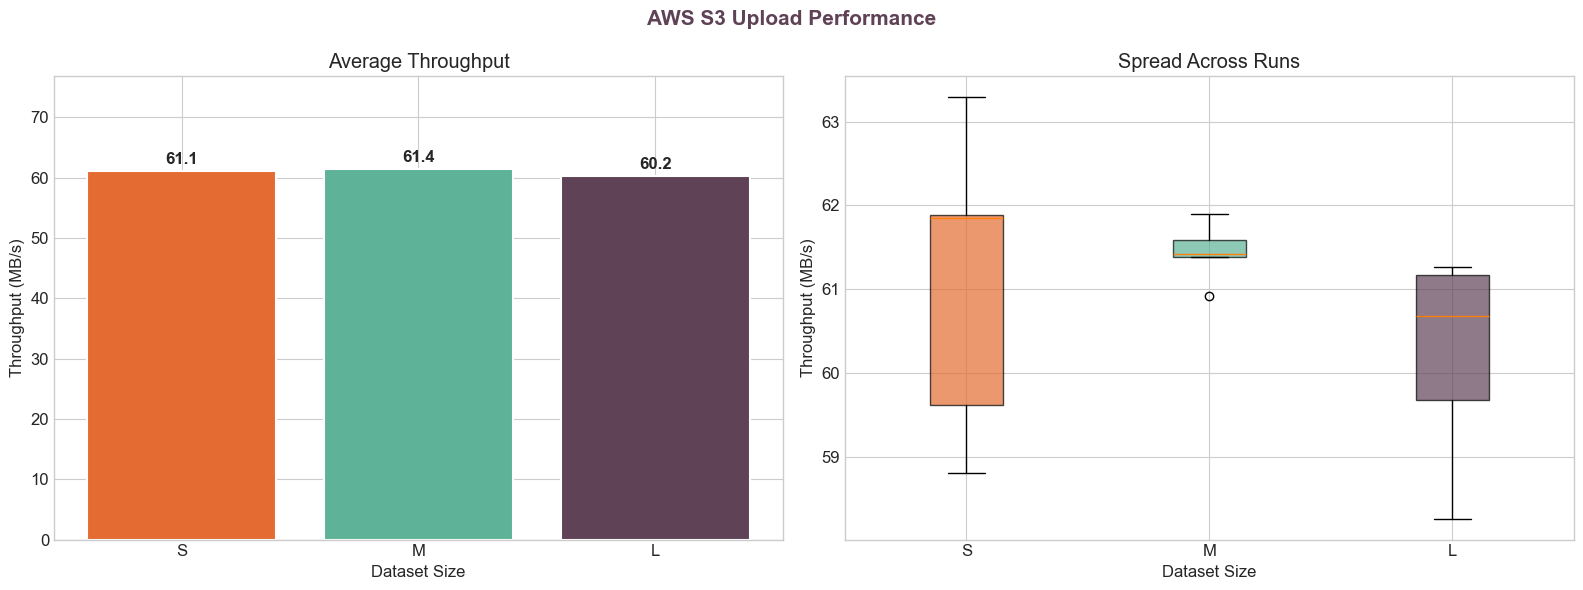

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
ax = axes[0]
bars = ax.bar(sizes, upload_avgs, color=SIZE_COLORS, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, upload_avgs):
    ax.annotate(f'{val:.1f}', xy=(bar.get_x() + bar.get_width()/2, val),
                xytext=(0, 5), textcoords="offset points", ha='center', fontsize=12, fontweight='bold')
ax.set_xlabel('Dataset Size')
ax.set_ylabel('Throughput (MB/s)')
ax.set_title('Average Throughput')
ax.set_ylim(0, max(upload_avgs) * 1.25)

# Box plot
ax = axes[1]
upload_data = [aws_runs[(aws_runs['size'] == s) & (aws_runs['operation'] == 'upload')]['throughput_mb_s'].values for s in sizes]
bp = ax.boxplot(upload_data, tick_labels=sizes, patch_artist=True)
for patch, color in zip(bp['boxes'], SIZE_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xlabel('Dataset Size')
ax.set_ylabel('Throughput (MB/s)')
ax.set_title('Spread Across Runs')

plt.suptitle('AWS S3 Upload Performance', fontsize=15, fontweight='bold', color=SHOWGIRL['plum'])
plt.tight_layout()
plt.savefig('results/aws_upload.png', dpi=150, bbox_inches='tight')
plt.show()


### AWS Download Throughput

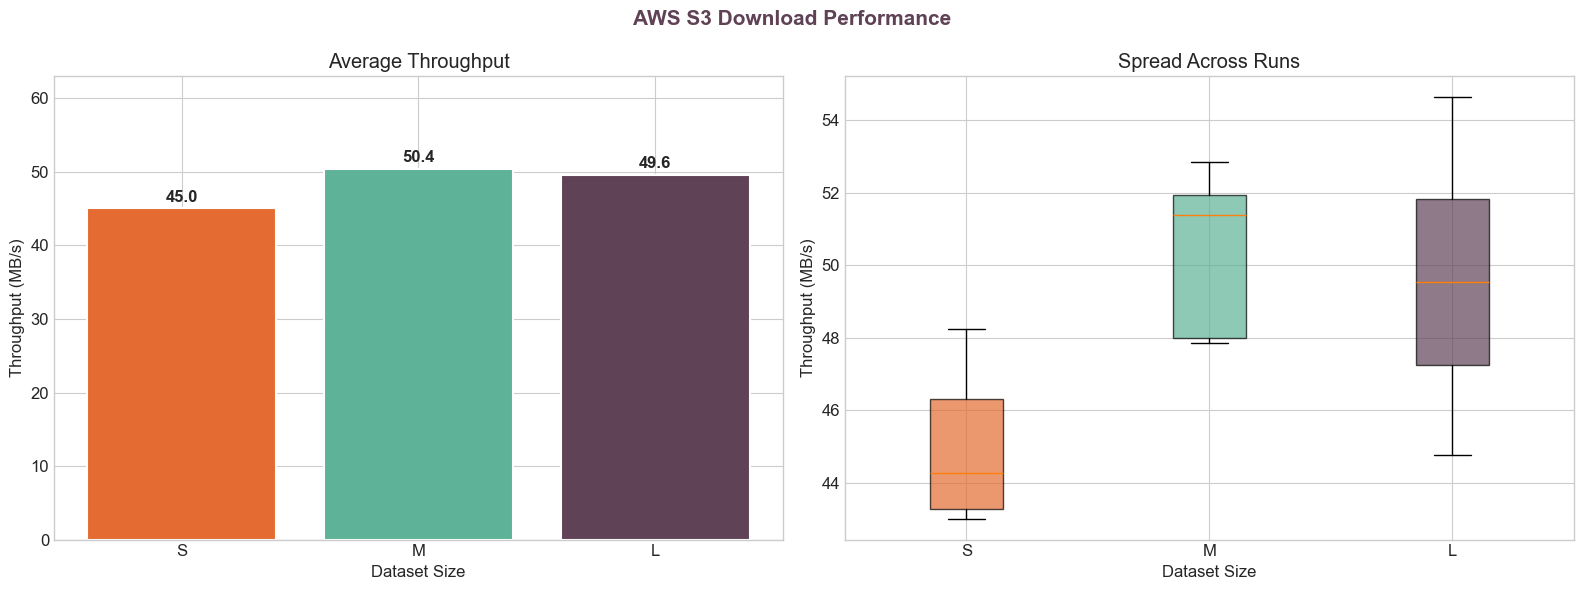

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
ax = axes[0]
bars = ax.bar(sizes, download_avgs, color=SIZE_COLORS, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, download_avgs):
    ax.annotate(f'{val:.1f}', xy=(bar.get_x() + bar.get_width()/2, val),
                xytext=(0, 5), textcoords="offset points", ha='center', fontsize=12, fontweight='bold')
ax.set_xlabel('Dataset Size')
ax.set_ylabel('Throughput (MB/s)')
ax.set_title('Average Throughput')
ax.set_ylim(0, max(download_avgs) * 1.25)

# Box plot
ax = axes[1]
download_data = [aws_runs[(aws_runs['size'] == s) & (aws_runs['operation'] == 'download')]['throughput_mb_s'].values for s in sizes]
bp = ax.boxplot(download_data, tick_labels=sizes, patch_artist=True)
for patch, color in zip(bp['boxes'], SIZE_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xlabel('Dataset Size')
ax.set_ylabel('Throughput (MB/s)')
ax.set_title('Spread Across Runs')

plt.suptitle('AWS S3 Download Performance', fontsize=15, fontweight='bold', color=SHOWGIRL['plum'])
plt.tight_layout()
plt.savefig('results/aws_download.png', dpi=150, bbox_inches='tight')
plt.show()


### AWS Scan Performance

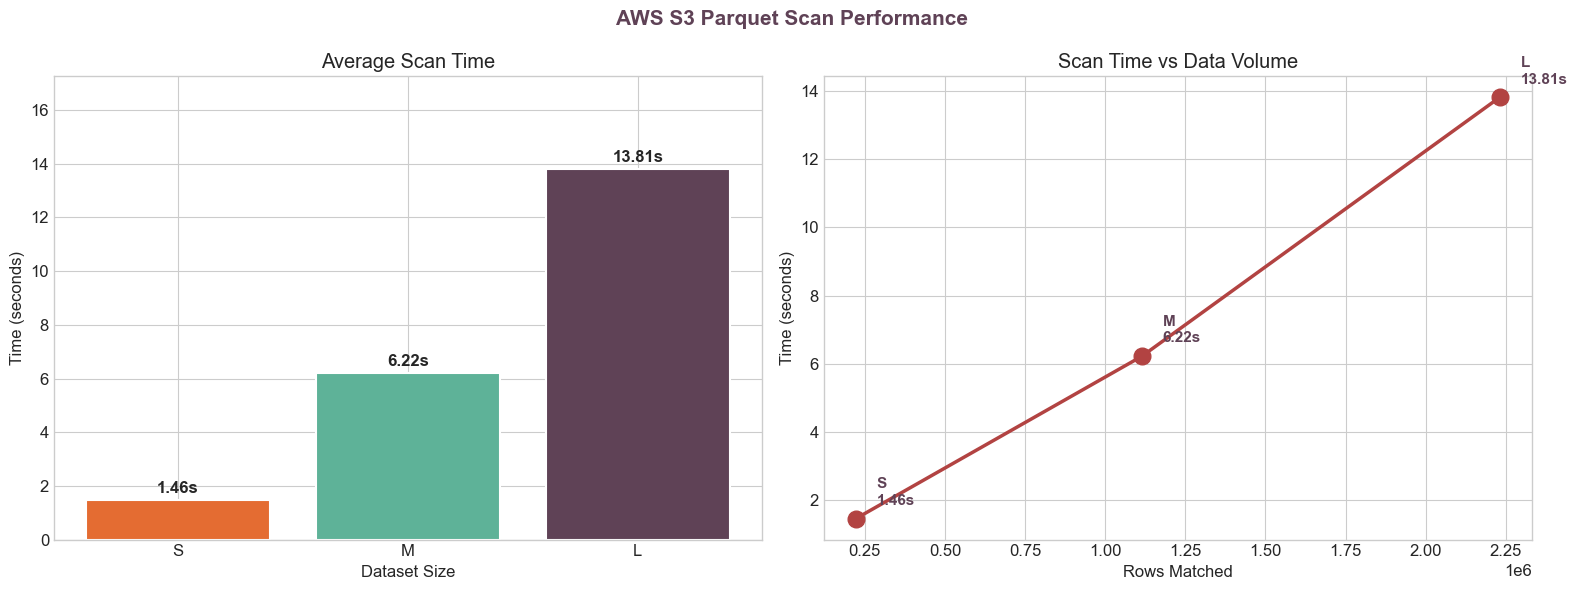

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
ax = axes[0]
bars = ax.bar(sizes, scan_avgs, color=SIZE_COLORS, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, scan_avgs):
    ax.annotate(f'{val:.2f}s', xy=(bar.get_x() + bar.get_width()/2, val),
                xytext=(0, 5), textcoords="offset points", ha='center', fontsize=12, fontweight='bold')
ax.set_xlabel('Dataset Size')
ax.set_ylabel('Time (seconds)')
ax.set_title('Average Scan Time')
ax.set_ylim(0, max(scan_avgs) * 1.25)

# Scan vs rows matched
ax = axes[1]
rows = [rows_matched[s] for s in sizes]
ax.plot(rows, scan_avgs, 'o-', color=SHOWGIRL['red'], linewidth=2.5, markersize=12)
for i, s in enumerate(sizes):
    ax.annotate(f'{s}\n{scan_avgs[i]:.2f}s', xy=(rows[i], scan_avgs[i]),
                xytext=(15, 10), textcoords="offset points", fontsize=11,
                color=SHOWGIRL['plum'], fontweight='bold')
ax.set_xlabel('Rows Matched')
ax.set_ylabel('Time (seconds)')
ax.set_title('Scan Time vs Data Volume')

plt.suptitle('AWS S3 Parquet Scan Performance', fontsize=15, fontweight='bold', color=SHOWGIRL['plum'])
plt.tight_layout()
plt.savefig('results/aws_scan.png', dpi=150, bbox_inches='tight')
plt.show()


### AWS Listing Performance

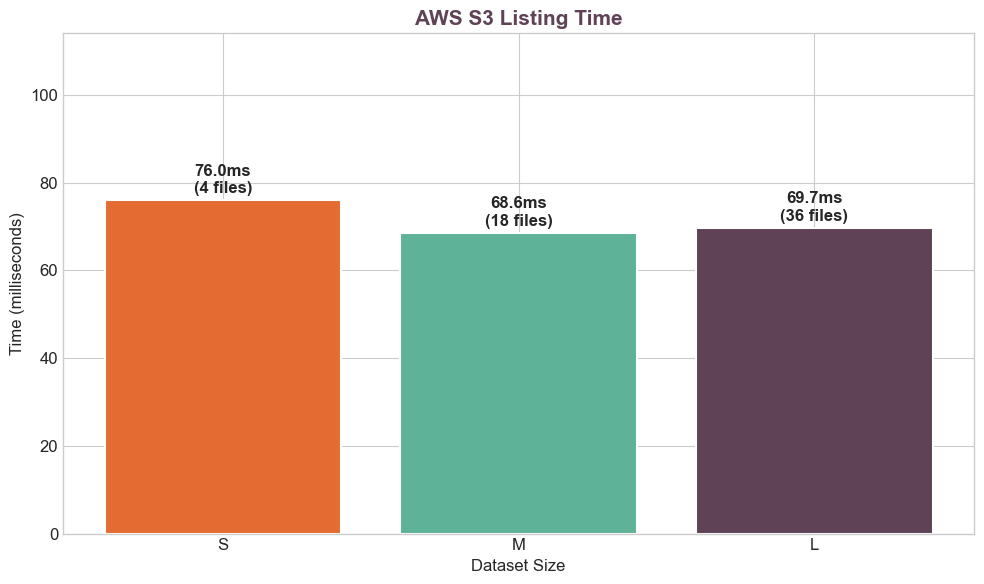

In [72]:
fig, ax = plt.subplots(figsize=(10, 6))

file_counts_list = [file_counts[s] for s in sizes]
bars = ax.bar(sizes, [v * 1000 for v in listing_avgs], color=SIZE_COLORS, edgecolor='white', linewidth=1.5)
for bar, val, fc in zip(bars, listing_avgs, file_counts_list):
    ax.annotate(f'{val*1000:.1f}ms\n({fc} files)', xy=(bar.get_x() + bar.get_width()/2, val * 1000),
                xytext=(0, 5), textcoords="offset points", ha='center', fontsize=12, fontweight='bold')

ax.set_xlabel('Dataset Size')
ax.set_ylabel('Time (milliseconds)')
ax.set_title('AWS S3 Listing Time', fontsize=15, fontweight='bold', color=SHOWGIRL['plum'])
ax.set_ylim(0, max(listing_avgs) * 1000 * 1.5)

plt.tight_layout()
plt.savefig('results/aws_listing.png', dpi=150, bbox_inches='tight')
plt.show()

### AWS Scaling Analysis

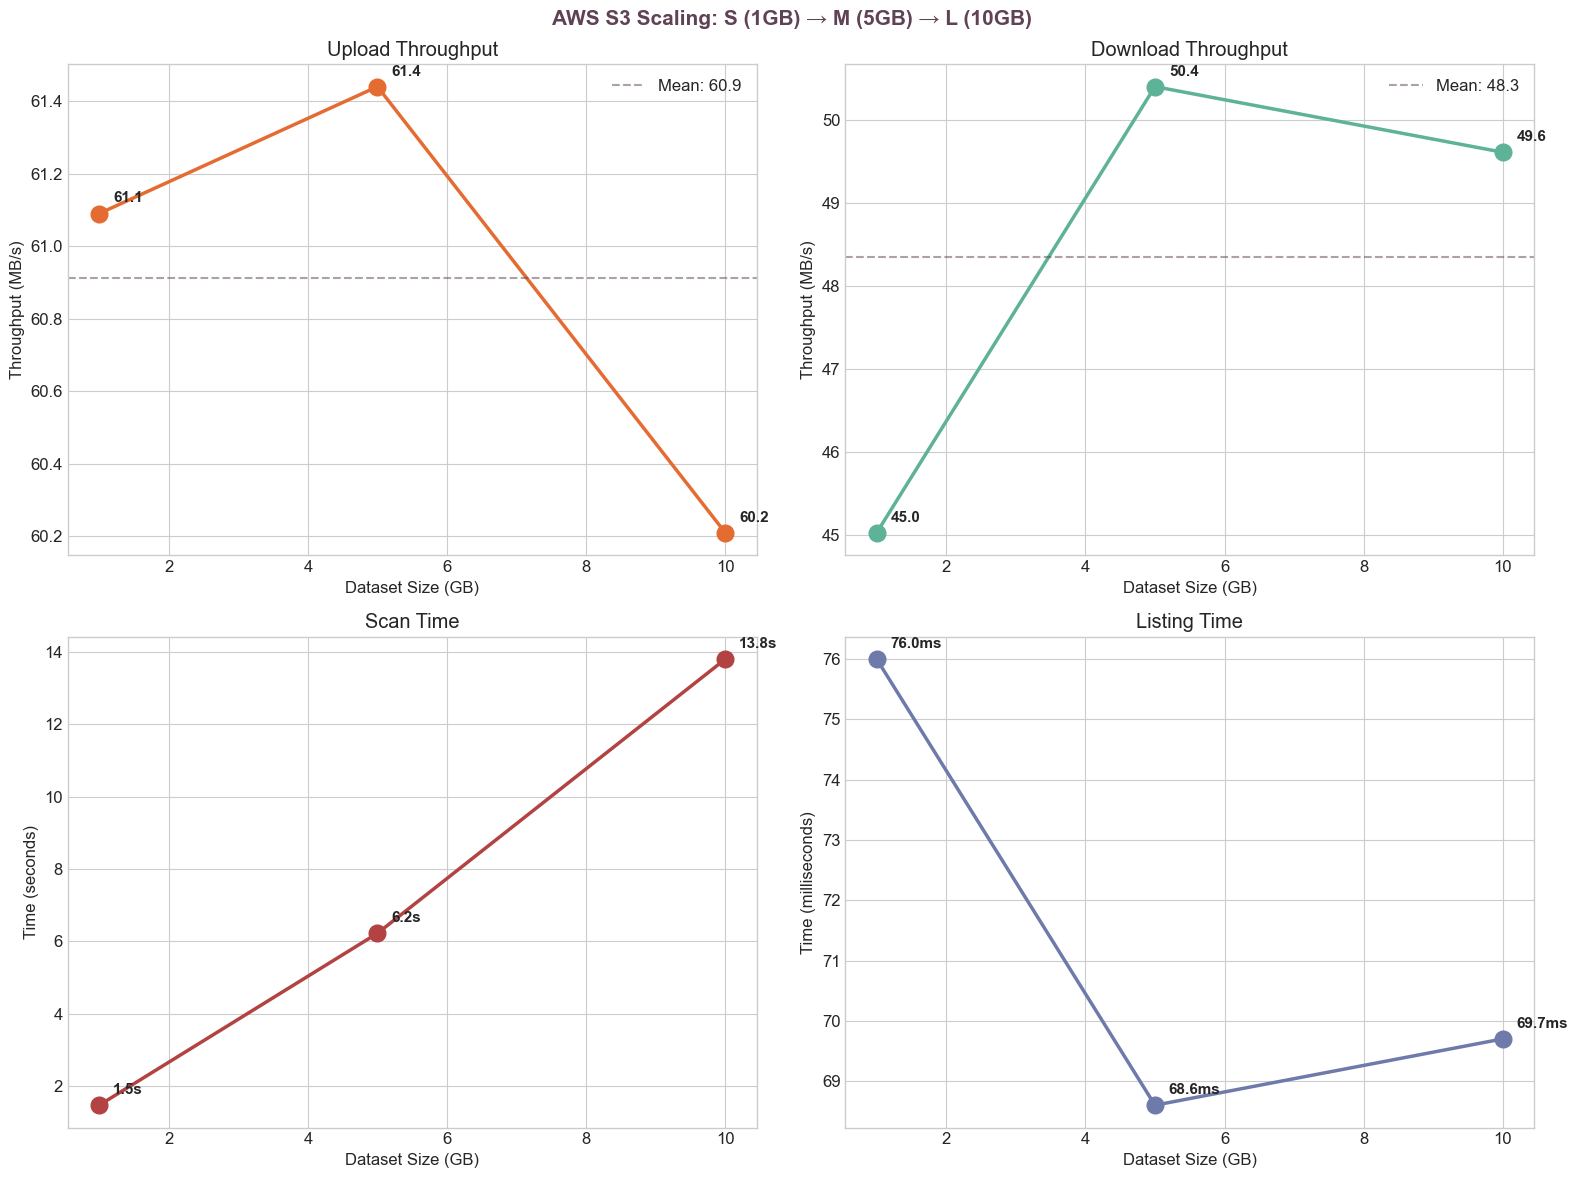

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

gb_values = [data_sizes_gb[s] for s in sizes]

# Upload
ax = axes[0][0]
ax.plot(gb_values, upload_avgs, 'o-', color=SHOWGIRL['orange'], linewidth=2.5, markersize=12)
for i, s in enumerate(sizes):
    ax.annotate(f'{upload_avgs[i]:.1f}', xy=(gb_values[i], upload_avgs[i]),
                xytext=(10, 8), textcoords="offset points", fontsize=11, fontweight='bold')
ax.set_xlabel('Dataset Size (GB)')
ax.set_ylabel('Throughput (MB/s)')
ax.set_title('Upload Throughput')
ax.axhline(y=np.mean(upload_avgs), color=SHOWGIRL['plum'], linestyle='--', alpha=0.5,
           label=f'Mean: {np.mean(upload_avgs):.1f}')
ax.legend()

# Download
ax = axes[0][1]
ax.plot(gb_values, download_avgs, 'o-', color=SHOWGIRL['teal'], linewidth=2.5, markersize=12)
for i, s in enumerate(sizes):
    ax.annotate(f'{download_avgs[i]:.1f}', xy=(gb_values[i], download_avgs[i]),
                xytext=(10, 8), textcoords="offset points", fontsize=11, fontweight='bold')
ax.set_xlabel('Dataset Size (GB)')
ax.set_ylabel('Throughput (MB/s)')
ax.set_title('Download Throughput')
ax.axhline(y=np.mean(download_avgs), color=SHOWGIRL['plum'], linestyle='--', alpha=0.5,
           label=f'Mean: {np.mean(download_avgs):.1f}')
ax.legend()

# Scan
ax = axes[1][0]
ax.plot(gb_values, scan_avgs, 'o-', color=SHOWGIRL['red'], linewidth=2.5, markersize=12)
for i, s in enumerate(sizes):
    ax.annotate(f'{scan_avgs[i]:.1f}s', xy=(gb_values[i], scan_avgs[i]),
                xytext=(10, 8), textcoords="offset points", fontsize=11, fontweight='bold')
ax.set_xlabel('Dataset Size (GB)')
ax.set_ylabel('Time (seconds)')
ax.set_title('Scan Time')

# Listing
ax = axes[1][1]
ax.plot(gb_values, [v * 1000 for v in listing_avgs], 'o-', color=SHOWGIRL['blue'], linewidth=2.5, markersize=12)
for i, s in enumerate(sizes):
    ax.annotate(f'{listing_avgs[i]*1000:.1f}ms', xy=(gb_values[i], listing_avgs[i] * 1000),
                xytext=(10, 8), textcoords="offset points", fontsize=11, fontweight='bold')
ax.set_xlabel('Dataset Size (GB)')
ax.set_ylabel('Time (milliseconds)')
ax.set_title('Listing Time')

plt.suptitle('AWS S3 Scaling: S (1GB) → M (5GB) → L (10GB)',
             fontsize=15, fontweight='bold', color=SHOWGIRL['plum'])
plt.tight_layout()
plt.savefig('results/aws_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

### AWS Run-by-Run Variance

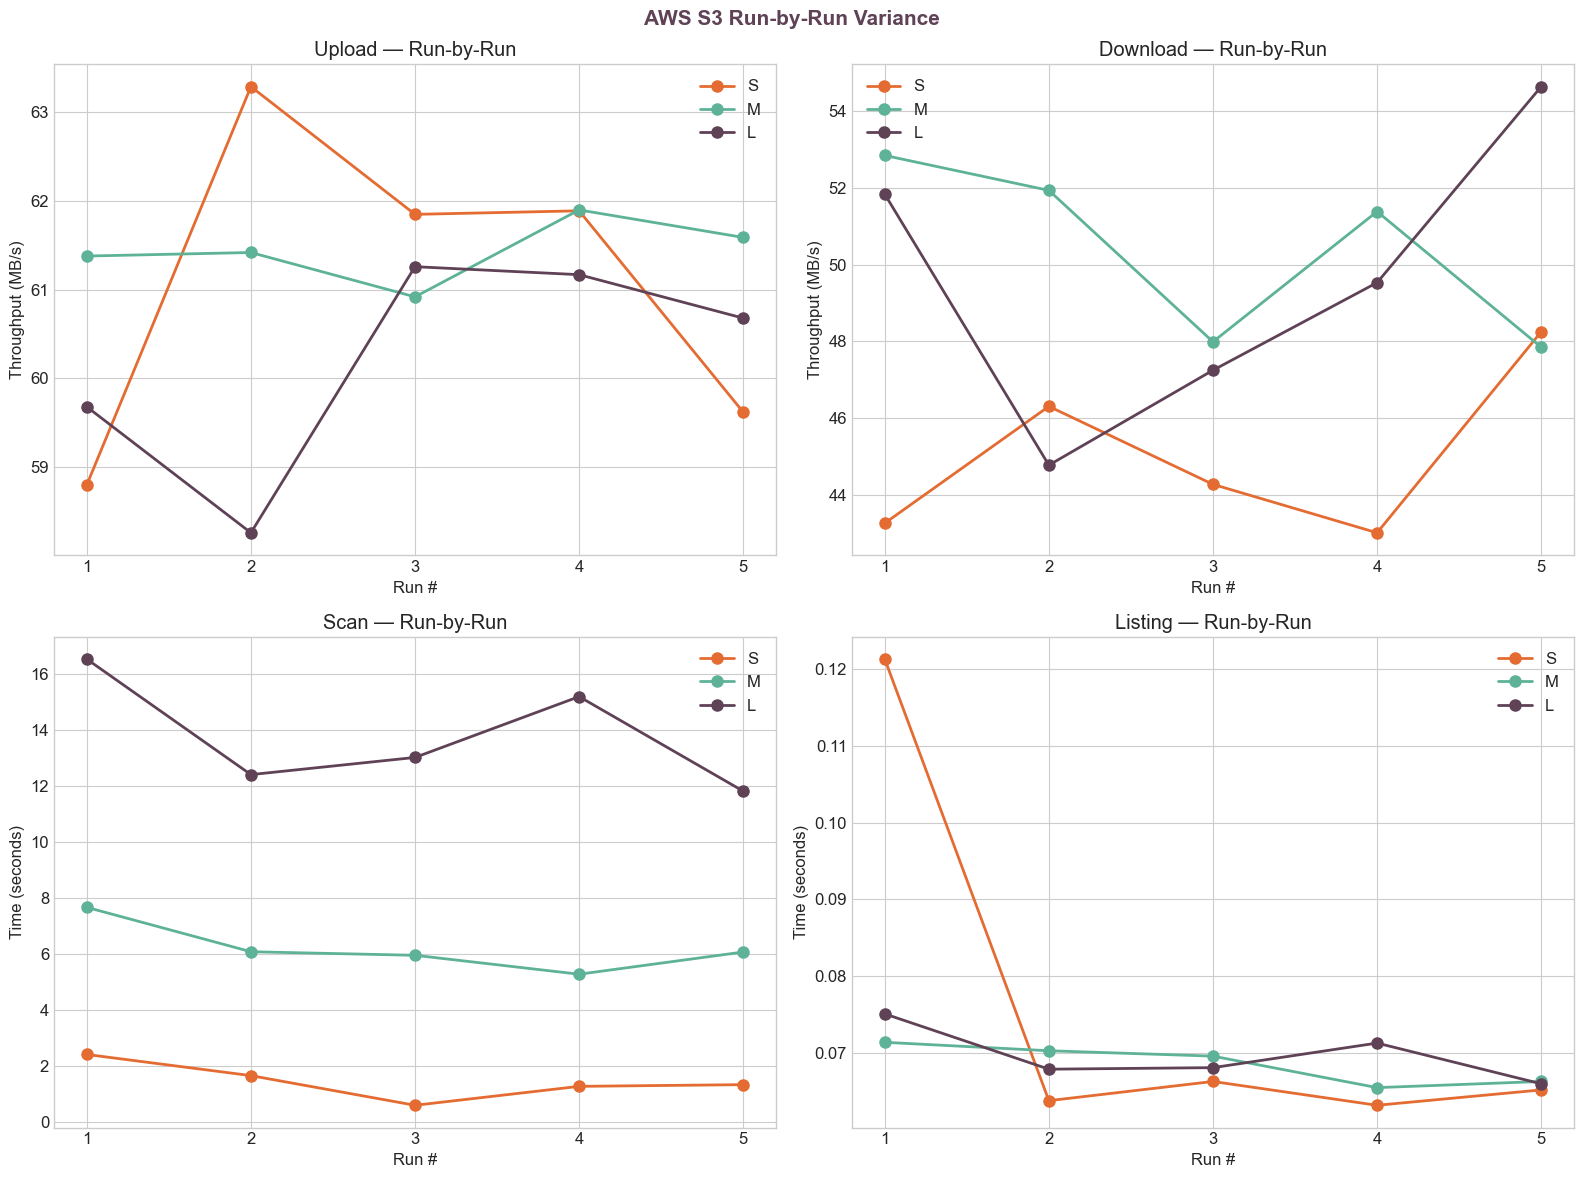

In [74]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ops = ['upload', 'download', 'scan', 'listing']
titles = ['Upload', 'Download', 'Scan', 'Listing']

for idx, (op, title) in enumerate(zip(ops, titles)):
    ax = axes[idx // 2][idx % 2]

    for i, s in enumerate(sizes):
        runs = aws_runs[(aws_runs['size'] == s) & (aws_runs['operation'] == op)]
        if op in ['upload', 'download']:
            values = runs['throughput_mb_s'].values
            ylabel = 'Throughput (MB/s)'
        else:
            values = runs['elapsed_s'].values
            ylabel = 'Time (seconds)'

        ax.plot(range(1, len(values) + 1), values, 'o-',
                label=s, linewidth=2, markersize=8, color=SIZE_COLORS[i])

    ax.set_xlabel('Run #')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{title} — Run-by-Run')
    ax.legend()
    ax.set_xticks(range(1, 6))

plt.suptitle('AWS S3 Run-by-Run Variance', fontsize=15, fontweight='bold', color=SHOWGIRL['plum'])
plt.tight_layout()
plt.savefig('results/aws_variance.png', dpi=150, bbox_inches='tight')
plt.show()


### AWS Key Findings

## AZURE

### Load Azure Data

In [75]:
print("✨" * 30)
print("   Azure Blob Storage Comparison")
print("✨" * 30)

df_azure = pd.read_csv('results/results-azure.csv')
df_azure_chunked = pd.read_csv('results/results-azure-chunking.csv')

# Azure file has duplicate S entries (first = no chunking, second = SDK tuned)
# Split by detecting when size+operation repeats
def split_azure_data(df):
    seen = {}
    first_block = []
    second_block = []

    for _, row in df.iterrows():
        if row['size'] == 'test':
            continue
        key = (row['size'], row['operation'], str(row['run']))
        if key not in seen:
            seen[key] = 1
            first_block.append(row)
        else:
            second_block.append(row)

    return pd.DataFrame(first_block), pd.DataFrame(second_block)

azure_slow, azure_fast = split_azure_data(df_azure)

azure_slow_avgs = azure_slow[azure_slow['run'] == 'avg']
azure_fast_avgs = azure_fast[azure_fast['run'] == 'avg'] if len(azure_fast) > 0 else pd.DataFrame()
azure_chunked_avgs = df_azure_chunked[
    (df_azure_chunked['run'] == 'avg') & (df_azure_chunked['size'].isin(sizes))
]

def get_avg_val(df, size, operation, field):
    row = df[(df['size'] == size) & (df['operation'] == operation)]
    if len(row) > 0 and field in row.columns:
        val = row[field].values[0]
        if pd.notna(val):
            return val
    return 0

# Pre-compute Azure averages
azure_slow_upload = [get_avg_val(azure_slow_avgs, s, 'upload', 'avg_throughput_mb_s') for s in sizes]
azure_slow_download = [get_avg_val(azure_slow_avgs, s, 'download', 'avg_throughput_mb_s') for s in sizes]
azure_slow_scan = [get_avg_val(azure_slow_avgs, s, 'scan', 'avg_elapsed_s') for s in sizes]
azure_slow_listing = [get_avg_val(azure_slow_avgs, s, 'listing', 'avg_elapsed_s') for s in sizes]

azure_chunk_upload = [get_avg_val(azure_chunked_avgs, s, 'upload', 'avg_throughput_mb_s') for s in sizes]
azure_chunk_download = [get_avg_val(azure_chunked_avgs, s, 'download', 'avg_throughput_mb_s') for s in sizes]
azure_chunk_scan = [get_avg_val(azure_chunked_avgs, s, 'scan', 'avg_elapsed_s') for s in sizes]
azure_chunk_listing = [get_avg_val(azure_chunked_avgs, s, 'listing', 'avg_elapsed_s') for s in sizes]

print("\n📊 Azure Averages Loaded:")
print(f"   No chunking upload (MB/s): {[f'{v:.1f}' for v in azure_slow_upload]}")
print(f"   Chunked upload (MB/s):     {[f'{v:.1f}' for v in azure_chunk_upload]}")
print(f"   No chunking download:      {[f'{v:.1f}' for v in azure_slow_download]}")
print(f"   Chunked download:          {[f'{v:.1f}' for v in azure_chunk_download]}")


✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨
   Azure Blob Storage Comparison
✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨

📊 Azure Averages Loaded:
   No chunking upload (MB/s): ['4.4', '8.0', '7.6']
   Chunked upload (MB/s):     ['54.0', '37.8', '45.8']
   No chunking download:      ['4.3', '21.8', '21.2']
   Chunked download:          ['40.6', '41.9', '40.0']


### AWS vs Azure Upload Comparison

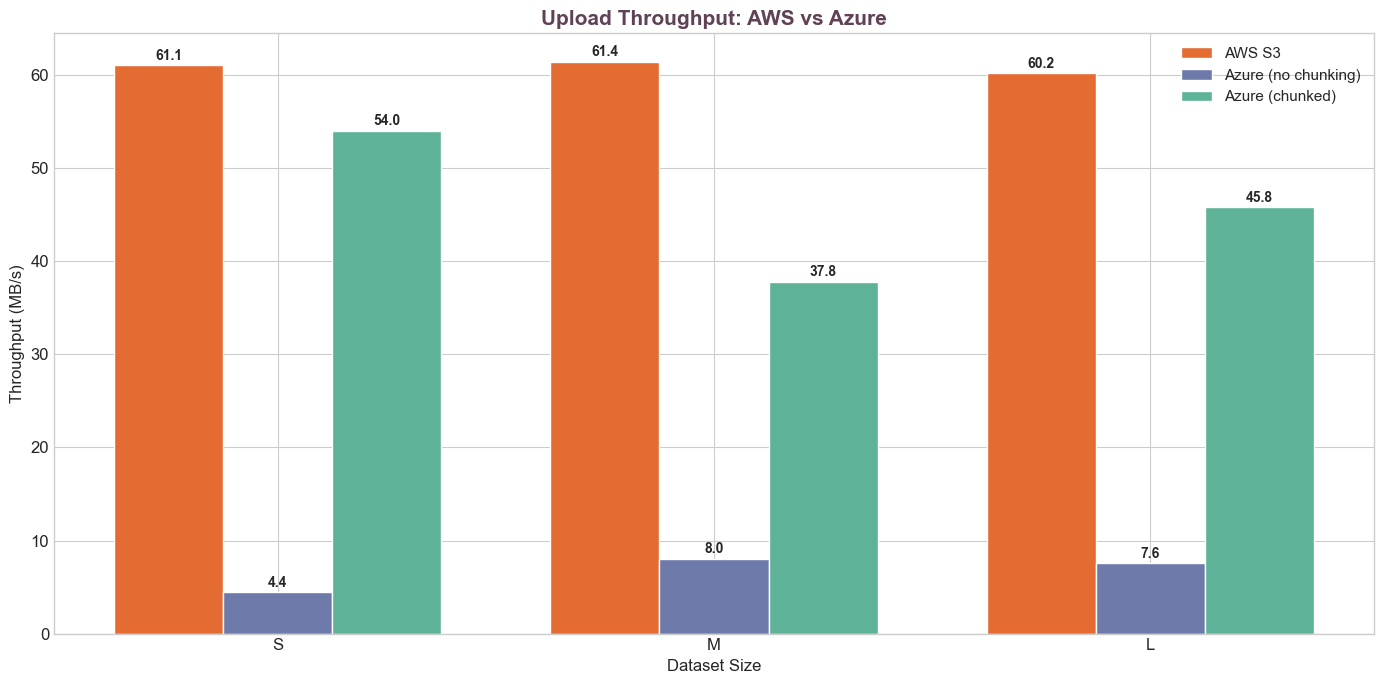

In [76]:
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(sizes))
width = 0.25

bars1 = ax.bar(x - width, upload_avgs, width, label='AWS S3', color=COLORS['aws'], edgecolor='white')
bars2 = ax.bar(x, azure_slow_upload, width, label='Azure (no chunking)', color=COLORS['azure_no_chunk'], edgecolor='white')
bars3 = ax.bar(x + width, azure_chunk_upload, width, label='Azure (chunked)', color=COLORS['azure_chunked'], edgecolor='white')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.annotate(f'{h:.1f}', xy=(bar.get_x() + bar.get_width()/2, h),
                        xytext=(0, 4), textcoords="offset points", ha='center',
                        fontsize=10, fontweight='bold')

ax.set_xlabel('Dataset Size')
ax.set_ylabel('Throughput (MB/s)')
ax.set_title('Upload Throughput: AWS vs Azure', fontsize=15, fontweight='bold', color=SHOWGIRL['plum'])
ax.set_xticks(x)
ax.set_xticklabels(sizes)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('results/bonus_upload_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### AWS vs Azure Download Comparison

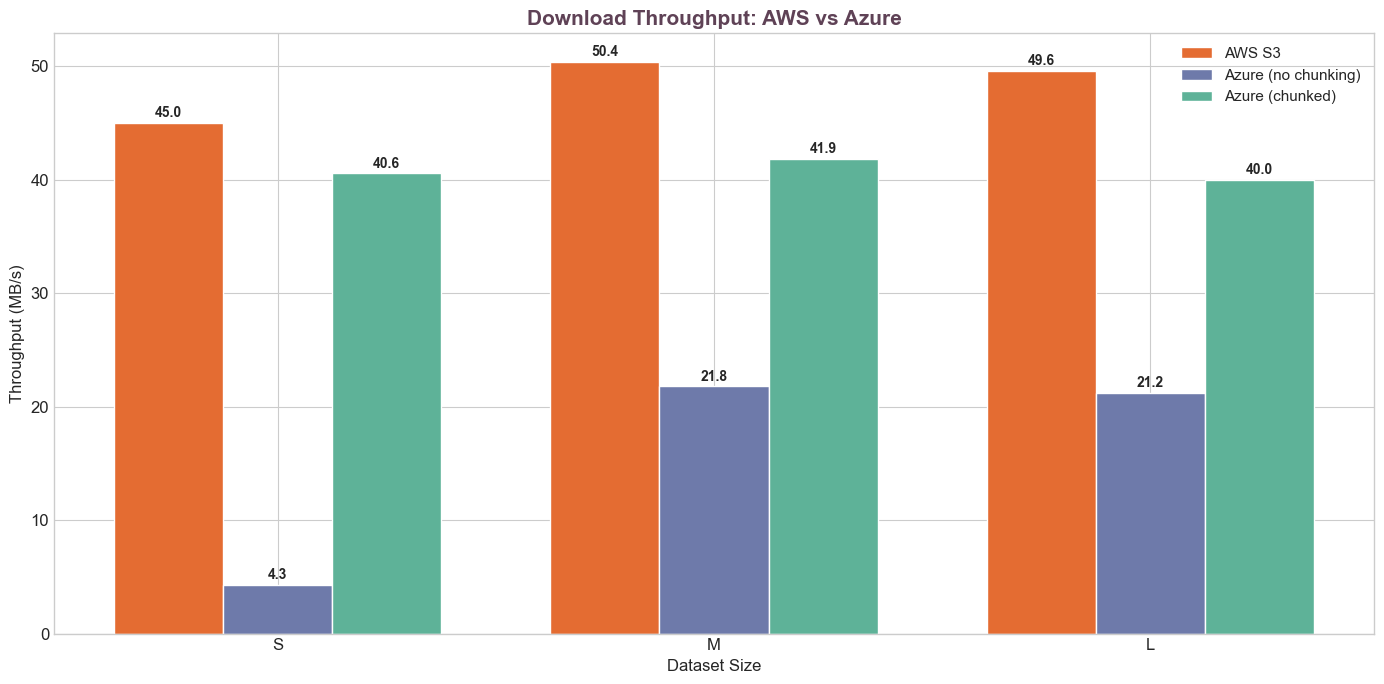

In [77]:
fig, ax = plt.subplots(figsize=(14, 7))

bars1 = ax.bar(x - width, download_avgs, width, label='AWS S3', color=COLORS['aws'], edgecolor='white')
bars2 = ax.bar(x, azure_slow_download, width, label='Azure (no chunking)', color=COLORS['azure_no_chunk'], edgecolor='white')
bars3 = ax.bar(x + width, azure_chunk_download, width, label='Azure (chunked)', color=COLORS['azure_chunked'], edgecolor='white')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.annotate(f'{h:.1f}', xy=(bar.get_x() + bar.get_width()/2, h),
                        xytext=(0, 4), textcoords="offset points", ha='center',
                        fontsize=10, fontweight='bold')

ax.set_xlabel('Dataset Size')
ax.set_ylabel('Throughput (MB/s)')
ax.set_title('Download Throughput: AWS vs Azure', fontsize=15, fontweight='bold', color=SHOWGIRL['plum'])
ax.set_xticks(x)
ax.set_xticklabels(sizes)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('results/bonus_download_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### AWS vs Azure Scan Comparison

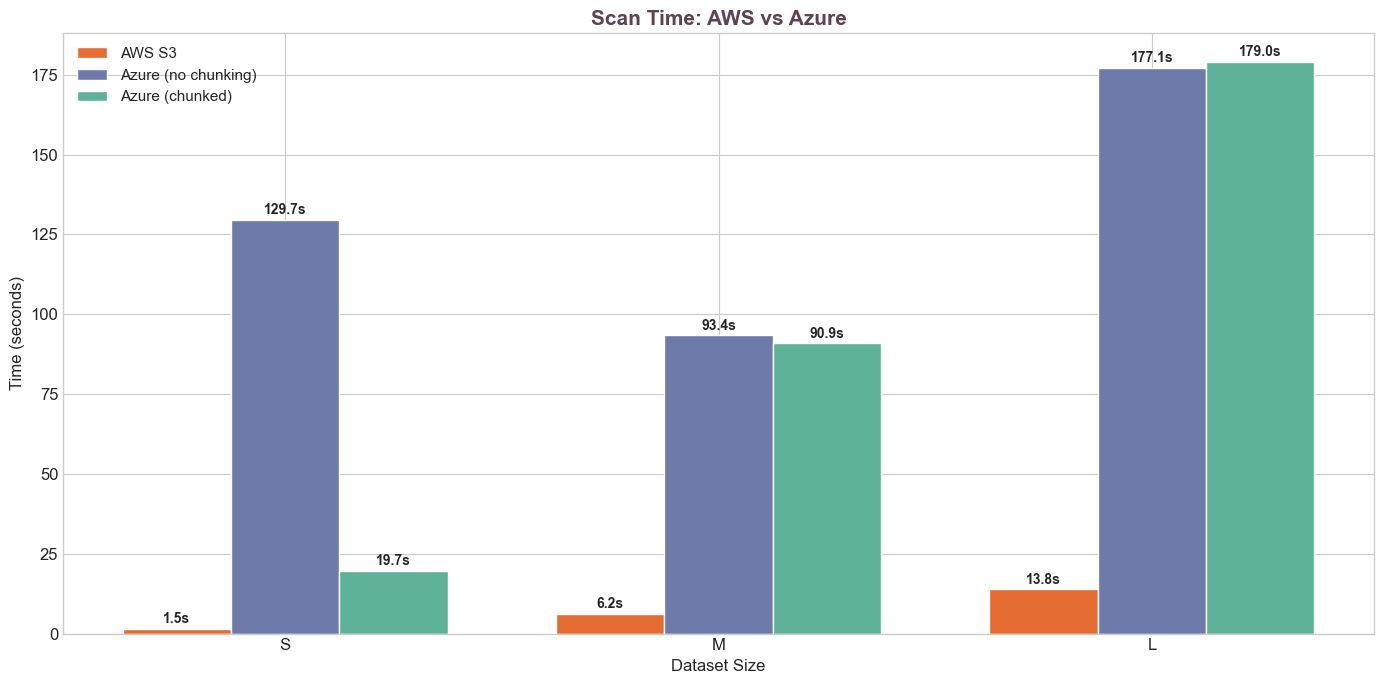

In [78]:
fig, ax = plt.subplots(figsize=(14, 7))

bars1 = ax.bar(x - width, scan_avgs, width, label='AWS S3', color=COLORS['aws'], edgecolor='white')
bars2 = ax.bar(x, azure_slow_scan, width, label='Azure (no chunking)', color=COLORS['azure_no_chunk'], edgecolor='white')
bars3 = ax.bar(x + width, azure_chunk_scan, width, label='Azure (chunked)', color=COLORS['azure_chunked'], edgecolor='white')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.annotate(f'{h:.1f}s', xy=(bar.get_x() + bar.get_width()/2, h),
                        xytext=(0, 4), textcoords="offset points", ha='center',
                        fontsize=10, fontweight='bold')

ax.set_xlabel('Dataset Size')
ax.set_ylabel('Time (seconds)')
ax.set_title('Scan Time: AWS vs Azure', fontsize=15, fontweight='bold', color=SHOWGIRL['plum'])
ax.set_xticks(x)
ax.set_xticklabels(sizes)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('results/bonus_scan_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Azure Chunking Impact

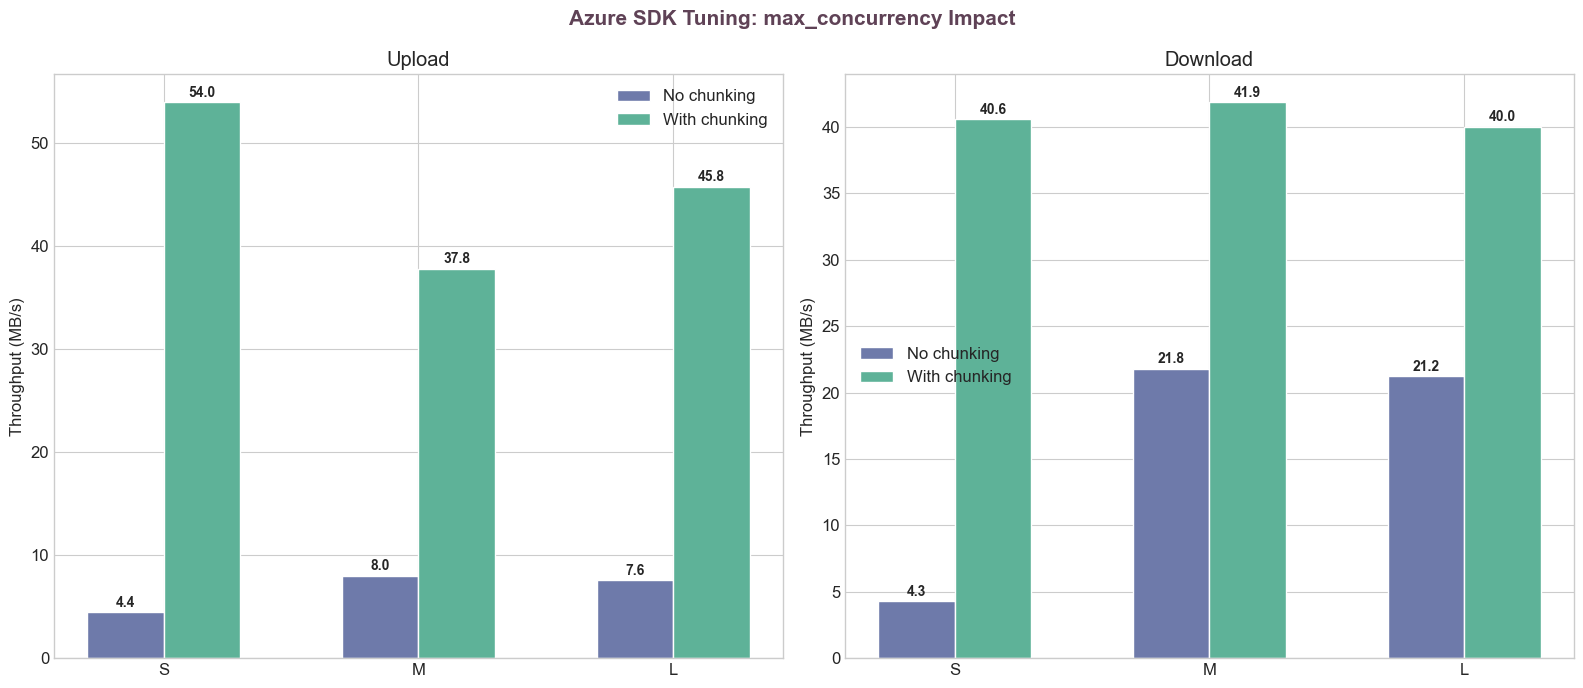


🚀 Azure Chunking Speedup:
Size   Operation    Before       After        Speedup   
-------------------------------------------------------
S      Upload       4.4          54.0         12.2      x
S      Download     4.3          40.6         9.4       x
M      Upload       8.0          37.8         4.7       x
M      Download     21.8         41.9         1.9       x
L      Upload       7.6          45.8         6.1       x
L      Download     21.2         40.0         1.9       x


In [79]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

x_pos = np.arange(len(sizes))

# Upload
ax = axes[0]
bars1 = ax.bar(x_pos - 0.15, azure_slow_upload, 0.3, label='No chunking', color=COLORS['azure_no_chunk'], edgecolor='white')
bars2 = ax.bar(x_pos + 0.15, azure_chunk_upload, 0.3, label='With chunking', color=COLORS['azure_chunked'], edgecolor='white')
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.annotate(f'{h:.1f}', xy=(bar.get_x() + bar.get_width()/2, h),
                        xytext=(0, 4), textcoords="offset points", ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(sizes)
ax.set_ylabel('Throughput (MB/s)')
ax.set_title('Upload')
ax.legend()

# Download
ax = axes[1]
bars1 = ax.bar(x_pos - 0.15, azure_slow_download, 0.3, label='No chunking', color=COLORS['azure_no_chunk'], edgecolor='white')
bars2 = ax.bar(x_pos + 0.15, azure_chunk_download, 0.3, label='With chunking', color=COLORS['azure_chunked'], edgecolor='white')
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.annotate(f'{h:.1f}', xy=(bar.get_x() + bar.get_width()/2, h),
                        xytext=(0, 4), textcoords="offset points", ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(sizes)
ax.set_ylabel('Throughput (MB/s)')
ax.set_title('Download')
ax.legend()

plt.suptitle('Azure SDK Tuning: max_concurrency Impact',
             fontsize=15, fontweight='bold', color=SHOWGIRL['plum'])
plt.tight_layout()
plt.savefig('results/bonus_azure_chunking.png', dpi=150, bbox_inches='tight')
plt.show()

# Speedup table
print("\n🚀 Azure Chunking Speedup:")
print("=" * 55)
print(f"{'Size':<6} {'Operation':<12} {'Before':<12} {'After':<12} {'Speedup':<10}")
print("-" * 55)
for s in sizes:
    slow_up = get_avg_val(azure_slow_avgs, s, 'upload', 'avg_throughput_mb_s')
    fast_up = get_avg_val(azure_chunked_avgs, s, 'upload', 'avg_throughput_mb_s')
    if slow_up > 0:
        print(f"{s:<6} {'Upload':<12} {slow_up:<12.1f} {fast_up:<12.1f} {fast_up/slow_up:<10.1f}x")

    slow_dl = get_avg_val(azure_slow_avgs, s, 'download', 'avg_throughput_mb_s')
    fast_dl = get_avg_val(azure_chunked_avgs, s, 'download', 'avg_throughput_mb_s')
    if slow_dl > 0:
        print(f"{s:<6} {'Download':<12} {slow_dl:<12.1f} {fast_dl:<12.1f} {fast_dl/slow_dl:<10.1f}x")


### Complete Summary & Recommendations